## Social Network Ads Purchase Prediction using Logistic Regression

### Project Overview :-
This notebook presents a machine learning classification project using the Social Network Ads dataset. The objective is to predict whether a customer will purchase a product based on demographic and salary-related features.


### Dataset Description :-

The Social Network Ads dataset contains customer information such as **Gender**, **Age**, and **Estimated Salary**, along with a target variable called **Purchased**, where 1 indicates purchase and 0 indicates no purchase. The goal of this project is to build a **Logistic Regression** model that predicts whether a customer will purchase a product based on these features.

The dataset contains **400 records** and **5 columns**:
- User ID
- Gender
- Age
- EstimatedSalary
- Purchased

In this notebook, `User ID` is removed because it does not contribute to the prediction task. The project includes data exploration, preprocessing, visualization, model training, and predi

### Objective :-
The main goal of this project is to apply Logistic Regression for binary classification and understand the complete workflow of data preprocessing, exploratory data analysis, model building, and prediction.


In [3]:
# Step 1 - Import Libraries

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [6]:
# Step 2 - Handling warnings by filtering it

warnings.filterwarnings('ignore')
%matplotlib inline

 Dataset :- https://www.kaggle.com/datasets/dragonheir/logistic-regression/data

In [1]:
pwd()

'C:\\Users\\adi89\\Github-Projects\\Mini Project 4 - Implement of Logistic Regression\\Notebook'

In [6]:
import os
os.chdir(r"C:\Users\adi89\Github-Projects\Mini Project 4 - Implement of Logistic Regression")
os.getcwd()

'C:\\Users\\adi89\\Github-Projects\\Mini Project 4 - Implement of Logistic Regression'

In [7]:
# Step 3 - Import & Read CSV file of dataset

ads_data = pd.read_csv("Dataset/Social_Network_Ads.csv")
ads_data


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
# Step 4 - Explore data and do necessary changes

In [ ]:
ads_data.nunique()

User ID            400
Gender               2
Age                 43
EstimatedSalary    117
Purchased            2
dtype: int64

In [ ]:
ads_data.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [ ]:
ads_data.duplicated().sum()

0

In [ ]:
ads_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [ ]:
ads_data.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,400.0,1.569154e+07,71658.321581,15566689.0,15626763.75,15694341.5,15750363.0,15815236.0
Age,400.0,3.765500e+01,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,6.974250e+04,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,3.575000e-01,0.479864,0.0,0.00,0.0,1.0,1.0


In [ ]:
data = ads_data.drop('User ID', axis = 1)
data

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


Step 5 - Visualization

In [ ]:
data['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

C:\Users\adi89\AppData\Local\Temp\ipykernel_29184\503920072.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Gender' , data = data, palette={'Male': 'lightblue', 'Female': 'pink'})


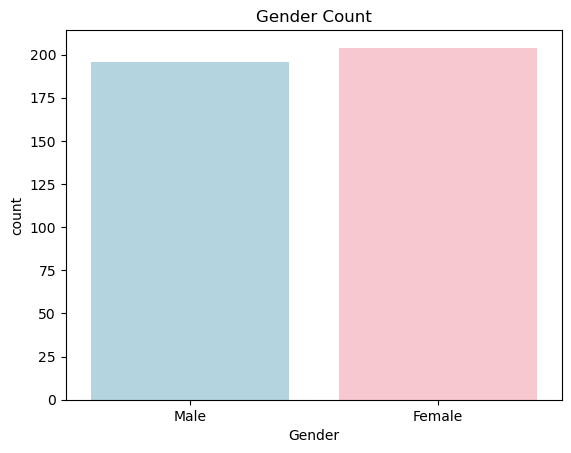

In [ ]:

sns.countplot(x = 'Gender' , data = data, palette={'Male': 'lightblue', 'Female': 'pink'})
plt.title("Gender Count")
plt.show()

In [ ]:
data['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

In [ ]:
data.groupby('Gender')['Purchased'].value_counts()

Gender  Purchased
Female  0            127
        1             77
Male    0            130
        1             66
Name: count, dtype: int64

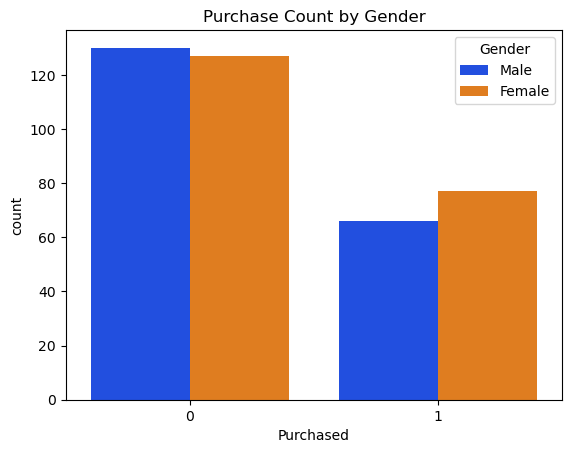

In [ ]:
sns.countplot(x = 'Purchased', hue = 'Gender', data = data, palette = 'bright')
plt.title("Purchase Count by Gender")
plt.show()

##### Step 6 - Preprocessing the data

In [ ]:
data2 = data['Gender'].factorize()[0]

In [ ]:
data3 = data.copy()

In [ ]:
data3['Gender'] = data2
data3

,Gender,Age,EstimatedSalary,Purchased
0,0,19,19000,0
1,0,35,20000,0
2,1,26,43000,0
3,1,27,57000,0
4,0,19,76000,0
...,...,...,...,...
395,1,46,41000,1
396,0,51,23000,1
397,1,50,20000,1
398,0,36,33000,0


##### Step 7 - Define X and Y

In [ ]:
X = data3.drop('Purchased', axis = 1)
y = data3['Purchased']

#### Step 8 - Spliting data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 12)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((280, 3), (120, 3), (280,), (120,))

### Step 9 - Fiting in Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_predicted = logreg.predict(X_test)
output = pd.DataFrame({
    "Prediction" : y_predicted,
    "Actual" : y_test})
output

,Prediction,Actual
280,1,1
387,0,0
313,1,1
1,0,0
35,0,0
...,...,...
284,1,0
266,0,0
190,0,0
176,0,0


#### Step 10 - Checking Accuracy of Model by Accuracy score & Confusion Matrix. And giving Conclusion based on that. 

In [ ]:
from sklearn.metrics import accuracy_score
print('Logistic Regression model Accuracy is {:.3f}'.format(accuracy_score(y_test, y_predicted)))

Logistic Regression model Accuracy is 0.825


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[61, 12],
       [ 9, 38]], dtype=int64)

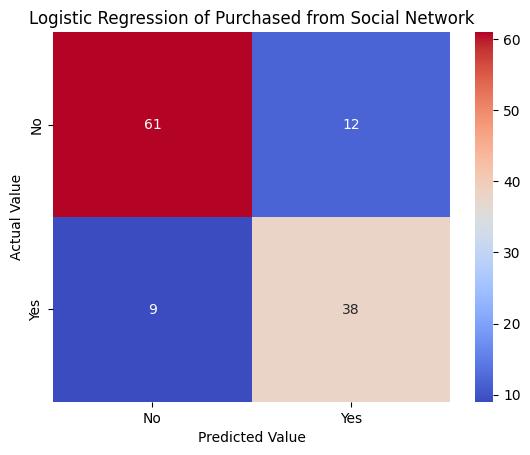

In [ ]:
sns.heatmap(cm, annot = True, cmap = 'coolwarm', xticklabels = ['No','Yes'], yticklabels = ['No','Yes'])
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Logistic Regression of Purchased from Social Network')
plt.show()

#### Conclusion :- 
**In my opinion Logistic Regression model given Accuracy is 0.825 which is pretty good because :
The features (Age, Salary, Gender) do not perfectly determine “Purchased”.**

There is noise and randomness in real user behavior.